## Importy

In [29]:
import numpy as np
import pandas as pd

import cv2
from PIL import Image
from torchvision import transforms

import tempfile
import os
import joblib
from ultralytics import YOLO

from segmentation.modelsUnet import UNet, preprocess_image, predict_masks
from segmentation.features import extract_features
from classification.models import CytologyClassifier, predict_label

from app.backend.helpers import *  

import matplotlib.pyplot as plt
import matplotlib.patches as patches

from dotenv import load_dotenv
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (accuracy_score, f1_score, recall_score, 
                             precision_score, classification_report, confusion_matrix)
from itertools import product
from tqdm import tqdm
import warnings
from utils import *
warnings.filterwarnings('ignore')
from ast import literal_eval
import re


## ŁADOWANIE MODELI 

In [30]:
load_dotenv()

CLASS_NAMES = os.getenv("CLASS_NAMES", "HSIL,LSIL,NSIL").split(",")
ARCHITECTURE = os.getenv("ARCHITECTURE", "resnet18")
CNN_MODEL_PATH = os.getenv("CNN_MODEL_PATH", r"C:\Users\aleks\OneDrive\Documents\inzynierka\classification\classification_models\resnet18\16_0_0001_50_1110.pth")
UNET_MODEL_PATH = os.getenv("UNET_MODEL_PATH", r"C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\unet_cell_nucleus_batch16_1_11.pth")
THRESHOLD_NUCLEI = float(os.getenv("THRESHOLD_NUCLEI", 0.6))
THRESHOLD_CELLS = float(os.getenv("THRESHOLD_CELLS", 0.4))
YOLO_MODEL_PATH = os.getenv("YOLO_MODEL_PATH", r"C:\Users\aleks\OneDrive\Documents\inzynierka\yolo_models\models\yolo_detector_2107_100_20_16_7682\weights\best.pt")
ML_MODEL_PATH = os.getenv("ML_MODEL_PATH", r'C:\Users\aleks\OneDrive\Documents\inzynierka\segmentation\models_paths\best_model_RandomForest_311.pkl')

def fuse_func(p1, p2, eps=1e-9):
    p = (p1 + eps) + (p2 + eps)
    return p / p.sum()
    
API_KEY = os.getenv("API_KEY", os.getenv("api_key", ''))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


unet = UNet(in_channels=3, out_channels=2)
unet.load_state_dict(torch.load(UNET_MODEL_PATH, map_location=device))
unet.to(device).eval()

yolo = YOLO(YOLO_MODEL_PATH)

ml_model = joblib.load(ML_MODEL_PATH)
label_encoder = ml_model['label_encoder']

cnn_classifier = CytologyClassifier(num_classes=len(CLASS_NAMES), architecture=ARCHITECTURE)
cnn_classifier.load(CNN_MODEL_PATH)
cnn_classifier.model.eval().to(device)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

## GŁÓWNY POTOK

In [31]:
def get_info(image_path, show_image=True):
    image = Image.open(image_path).convert("RGB")
    image_np = np.array(image)

    results = yolo(image_path, conf=0.25, iou=0.5, agnostic_nms=False)
    boxes_tensor = results[0].boxes.xyxy.cpu()
    classes_tensor = results[0].boxes.cls.cpu().int()

    boxes_array = boxes_tensor.numpy()
    keep_ids = nms_keep_largest_box(boxes_array, iou_thresh=0.4)

    boxes_tensor = boxes_tensor[keep_ids]
    classes_tensor = classes_tensor[keep_ids]

    cell_mask = (classes_tensor == 0) | (classes_tensor == 1) | (classes_tensor == 2)
    boxes = boxes_tensor[cell_mask].numpy().astype(int)

    predicted_classes_cnn = {}
    predicted_classed_ml = {}
    predicted_classed_fused = {}
    features_list = {}
    probs = {}
    crop_paths = {}
    probs_list = []

    bbox_image_path = None
    if show_image:
        fig, ax = plt.subplots(figsize=(7.68, 5.12), dpi=100)
        ax.imshow(image_np)
        for idx, (x1, y1, x2, y2) in enumerate(boxes):
            rect = patches.Rectangle(
                (x1, y1), x2 - x1, y2 - y1,
                linewidth=2,
                edgecolor= '#f7c873',
                facecolor='none'
            )
            ax.add_patch(rect)
            ax.text(
                x1, max(0, y1 - 5), str(idx),
                color='#3a5ba0',  
                fontsize=12, weight='bold',
                bbox=dict(facecolor='white', alpha=0.5, edgecolor='none')
            )
        ax.set_axis_off()
        plt.show()
        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp_bbox:
            fig.savefig(tmp_bbox.name, bbox_inches='tight', pad_inches=0, dpi=100)
            bbox_image_path = tmp_bbox.name
        plt.close(fig)
        im = Image.open(bbox_image_path)
        im = im.resize((768, 512), Image.LANCZOS)
        im.save(bbox_image_path)

    for idx, (x1, y1, x2, y2) in enumerate(boxes):
        crop = image_np[y1:y2, x1:x2]
        if crop.size == 0:
            continue

        yolo_class = None
        for i, box in enumerate(boxes_tensor.numpy().astype(int)):
            if np.array_equal(box, [x1, y1, x2, y2]):
                yolo_class = int(classes_tensor[i].item())
                break

        with tempfile.NamedTemporaryFile(suffix='.png', delete=False) as tmp_crop:
            cv2.imwrite(tmp_crop.name, cv2.cvtColor(crop, cv2.COLOR_RGB2BGR))
            tmp_path = tmp_crop.name
            crop_paths[idx] = tmp_path

        if yolo_class == 1:
            predicted_classes_cnn[idx] = 'HSIL/LSIL_group'
            predicted_classed_fused[idx] = 'HSIL/LSIL_group'
            probs_list.append([0.7, 0.3, 0])
            continue

        _, tensor = preprocess_image(tmp_path)
        masks = predict_masks(unet, tensor, device, threshold_nuclei=THRESHOLD_NUCLEI, threshold_cell=THRESHOLD_CELLS)
        mask_nucleus = cv2.resize(masks[1], (crop.shape[1], crop.shape[0]))
        best_nucleus = select_best_nucleus(mask_nucleus, crop.shape[:2])
        mask_cell = cv2.resize(masks[0], (crop.shape[1], crop.shape[0])) * 255

        features = extract_features(best_nucleus, mask_cell)
        
        if features is None or len(features) == 0:
            print(f"Pominięto komórkę {idx} - brak features")
            continue
            
        if all(value == 0 for value in features.values()):
            print(f"Pominięto komórkę {idx} - wszystkie features równe 0")
            continue
            
        features_list[idx] = features

        predict_class_ml = predict_ml(ml_model['model'], label_encoder, features)
        predicted_classed_ml[idx] = predict_class_ml

        predict_class_cnn = predict_label(cnn_classifier, crop)
        predicted_classes_cnn[idx] = predict_class_cnn[0]

        predicted_clas_fused = predict_fused_func_2(fuse_func, ml_model["model"], label_encoder, cnn_classifier, unet, device, tmp_path)
        predicted_classed_fused[idx] = predicted_clas_fused

        probs_fused = predict_fused_func_2(fuse_func, ml_model["model"], label_encoder, cnn_classifier, unet, device, tmp_path, True)
        
        probs[idx] = {
            'fused': probs_fused
        }
        probs_list.append(probs_fused)
    
    all_indices = set(predicted_classes_cnn.keys()) | set(predicted_classed_ml.keys()) | set(predicted_classed_fused.keys())
    rows = []
    for idx in sorted(all_indices):
        rows.append({
            "idx": idx,
            "predict_vgg": predicted_classes_cnn.get(idx, None),
            "predict_gbm": predicted_classed_ml.get(idx, None),
            "predicted_classed_fused": predicted_classed_fused.get(idx, None),
        })

    df_preds = pd.DataFrame(rows)

    return features_list, predicted_classed_fused, probs, probs_list, df_preds, bbox_image_path, crop_paths

    


## FUNKCJE POMOCNICZE

In [32]:


def _to_2d_float_array(cell_probs):
    if isinstance(cell_probs, str):
        s = cell_probs.strip()
        s = re.sub(r'\barray\(\s*', '', s)
        s = re.sub(r',\s*dtype=[^)]+\)', ')', s)
        s = s.replace(')', '')
        arr = np.asarray(literal_eval(s), dtype=float)
    else:
        arr = np.asarray(cell_probs, dtype=float)

    arr = np.squeeze(arr)

    if arr.ndim == 1:
        arr = arr[None, :]

    if arr.ndim != 2:
        raise ValueError(f"Oczekiwano tablicy 2D, dostałem {arr.shape} (ndim={arr.ndim})")

    return arr


In [33]:
def class_weighted_pooling(cell_probs, class_weights=[3.0, 1.5, 1.0], pooling='max'):
    if len(cell_probs) == 0:
        return None
    
    weighted_probs = _to_2d_float_array(cell_probs)  * np.array(class_weights)
    
    if pooling == 'max':
        slide_probs_weighted = np.max(weighted_probs, axis=0)
    elif pooling == 'mean':
        slide_probs_weighted = np.mean(weighted_probs, axis=0)
    else:
        raise ValueError(f"Unknown pooling: {pooling}")
    
    slide_probs = slide_probs_weighted / slide_probs_weighted.sum()
    return slide_probs

In [34]:
def load_cell_probabilities_from_folder(folder_path, class_name, class_to_idx):
    slides = []
    labels = []
    filenames = []
    
    if not os.path.exists(folder_path):
        print(f"Folder nie istnieje: {folder_path}")
        return slides, labels, filenames
    
    files = [f for f in os.listdir(folder_path) if f.endswith(('.bmp'))]
    
    for filename in files:
        file_path = os.path.join(folder_path, filename)
        features_list, predicted_classed_fused, cell_probs, df_preds, bbox_image_path, crop_pat = get_info(file_path, show_image=False)

        if len(cell_probs) == 0:
                print(f"Brak komórek w {filename}, pomijam...")
                continue
        slides.append(cell_probs)
        labels.append(class_to_idx[class_name])
        filenames.append(filename)
            
    return slides, labels, filenames

def load_all_data(base_path, class_names):

    class_to_idx = {name: idx for idx, name in enumerate(class_names)}
    
    train_slides, train_labels, train_files = [], [], []
    test_slides, test_labels, test_files = [], [], []
    
    print("\nWczytuję dane treningowe...")
    train_path = os.path.join(base_path, 'train')
    for class_name in class_names:
        folder_path = os.path.join(train_path, class_name)
        slides, labels, files = load_cell_probabilities_from_folder(
            folder_path, class_name, class_to_idx
        )
        train_slides.extend(slides)
        train_labels.extend(labels)
        train_files.extend(files)
        print(f"  {class_name}: {len(slides)} slajdów")
    
    print("\nWczytuję dane testowe...")
    test_path = os.path.join(base_path, 'test')
    for class_name in class_names:
        folder_path = os.path.join(test_path, class_name)
        slides, labels, files = load_cell_probabilities_from_folder(
            folder_path, class_name, class_to_idx
        )
        test_slides.extend(slides)
        test_labels.extend(labels)
        test_files.extend(files)
        print(f"  {class_name}: {len(slides)} slajdów")
    
    train_data = {
        'slides': train_slides,
        'labels': np.array(train_labels),
        'filenames': train_files
    }
    
    test_data = {
        'slides': test_slides,
        'labels': np.array(test_labels),
        'filenames': test_files
    }
    
    print(f"\n✓ Wczytano:")
    print(f"  Train: {len(train_slides)} slajdów")
    print(f"  Test: {len(test_slides)} slajdów")
    
    return train_data, test_data

In [35]:
# BASE_PATH = r"C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_dataset2"
# CLASS_NAMES = ['HSIL', 'LSIL', 'NSIL']  
    
# print("="*70)
# print("OPTYMALIZACJA WAG + PORÓWNANIE MAX vs MEAN POOLING")
# print("="*70)
# print(f"\nŚcieżka bazowa: {BASE_PATH}")
# print(f"Klasy: {CLASS_NAMES}")
# print(f"\n⚠️  UWAGA: Format prawdopodobieństw w plikach: [p_HSIL, p_LSIL, p_NSIL]")
    
# train_data_2, test_data_2 = load_all_data(BASE_PATH, CLASS_NAMES)

## DANE

In [36]:
import pandas as pd
from sklearn.model_selection import train_test_split

df_train = pd.read_csv('wyniki_excel/DANE_Z_GROUP.csv')
df_test  = pd.read_csv('wyniki_excel/DANE_Z_GROUP_test.csv')

df_all = pd.concat([df_train, df_test], ignore_index=True)

use_stratify = False
if 'labels' in df_all.columns:
    value_counts = df_all['labels'].value_counts()
    use_stratify = (value_counts.min() >= 2) and (value_counts.nunique() > 0)

train_df, test_df = train_test_split(
    df_all,
    test_size=0.15,
    random_state=42,
    shuffle=True,
    stratify=df_all['labels'] if use_stratify else None
)

train_data = {
    'slides':    train_df['slides'].tolist(),
    'labels':    train_df['labels'].tolist(),
    'filenames': train_df['filenames'].tolist()
}

test_data = {
    'slides':    test_df['slides'].tolist(),
    'labels':    test_df['labels'].tolist(),
    'filenames': test_df['filenames'].tolist()
}

print(f"Łącznie: {len(df_all)} | Train: {len(train_df)} | Test: {len(test_df)}")


Łącznie: 387 | Train: 328 | Test: 59


In [37]:
def calculate_metrics(y_true, y_pred, class_names):
    """Oblicz wszystkie metryki"""
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    recall_per_class = recall_score(y_true, y_pred, labels=[0, 1, 2], 
                                    average=None, zero_division=0)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    hsil_recall = recall_per_class[0] if len(recall_per_class) > 2 else 0.0
    
    return {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'hsil_recall': hsil_recall,
        'recall': recall,
        'precision': precision
    }

## WAŻONA AGREGACJA

In [38]:

def cross_validated_weight_search(train_data, class_names, n_splits=5):

    print("\n" + "="*70)
    print("CROSS-VALIDATION GRID SEARCH - MAX vs MEAN POOLING")
    print("="*70)
    
    hsil_weights = [2.0, 3.0, 4.0, 5.0, 7.0]
    lsil_weights = [1.0, 1.5, 2.0, 2.5, 3.0]
    nilm_weights = [1.0]  
    
    pooling_methods = ['max', 'mean']
    
    all_combinations = list(product(hsil_weights, lsil_weights, nilm_weights, pooling_methods))
    print(f"\nLiczba kombinacji do przetestowania: {len(all_combinations)}")
    print(f"  - Metody poolingu: {pooling_methods}")
    print(f"  - Wagi HSIL: {hsil_weights}")
    print(f"  - Wagi LSIL: {lsil_weights}")
    print(f"  - Wagi NILM: {nilm_weights}")
    print(f"\nFolds: {n_splits}")
    print(f"Łącznie ewaluacji: {len(all_combinations) * n_splits}")
    
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    results = []
    
    for w_hsil, w_lsil, w_nilm, pooling in tqdm(all_combinations, desc="Grid Search"):
        class_weights = [w_hsil, w_lsil, w_nilm] 
        fold_metrics = {
            'accuracy': [],
            'f1_macro': [],
            'recall': [],
            'precision': [],
            'hsil_recall': []
        }
        
        for fold_idx, (train_idx, val_idx) in enumerate(skf.split(train_data['slides'], 
                                                                   train_data['labels'])):
            val_slides = [train_data['slides'][i] for i in val_idx]
            # val_labels = train_data['labels'][val_idx]
            val_labels = [train_data['labels'][i] for i in val_idx]

            
            val_preds = []
            for cell_probs in val_slides:
                slide_probs = class_weighted_pooling(cell_probs, class_weights, pooling)
                if slide_probs is not None:
                    val_preds.append(np.argmax(slide_probs))
                else:
                    val_preds.append(2)  
            
            val_preds = np.array(val_preds)
            
            metrics = calculate_metrics(val_labels, val_preds, class_names)
            
            fold_metrics['accuracy'].append(metrics['accuracy'])
            fold_metrics['f1_macro'].append(metrics['f1_macro'])
            fold_metrics['precision'].append(metrics['precision'])
            fold_metrics['recall'].append(metrics['recall'])
            fold_metrics['hsil_recall'].append(metrics['hsil_recall'])
        
        results.append({
            'pooling': pooling,
            'w_hsil': w_hsil,
            'w_lsil': w_lsil,
            'w_nilm': w_nilm,
            'weights': class_weights,
            'mean_accuracy': np.mean(fold_metrics['accuracy']),
            'std_accuracy': np.std(fold_metrics['accuracy']),
            'mean_precision': np.mean(fold_metrics['precision']),
            'std_precision': np.std(fold_metrics['precision']),
            'mean_recall': np.mean(fold_metrics['recall']),
            'std_recall': np.std(fold_metrics['recall']),
            'mean_f1': np.mean(fold_metrics['f1_macro']),
            'std_f1': np.std(fold_metrics['f1_macro']),
            'mean_hsil_recall': np.mean(fold_metrics['hsil_recall']),
            'std_hsil_recall': np.std(fold_metrics['hsil_recall']),

        })
    
    results_df = pd.DataFrame(results)
    results_df = results_df.sort_values('mean_f1', ascending=False)
    
    best = results_df.iloc[0]
    best_config = {
        'pooling': best['pooling'],
        'weights': [best['w_hsil'], best['w_lsil'], best['w_nilm']],
        'metrics': {
            'accuracy': best['mean_accuracy'],
            'f1_macro': best['mean_f1'],
            'precision': best['mean_precision'],
            'recall': best['mean_recall'],
            'hsil_recall': best['mean_hsil_recall'],
        }
    }
    
    print("\n" + "="*70)
    print("WYNIKI")
    print("="*70)
    
    print(f"\n📊 Top 10 konfiguracji:")
    print(results_df.head(10)[['pooling', 'weights', 'mean_accuracy', 'mean_f1', 
                                'mean_hsil_recall']])
    
    return best_config, results_df

In [39]:
N_SPLITS = 5  
best_config, results_df = cross_validated_weight_search(train_data, CLASS_NAMES, n_splits=N_SPLITS)
results_df.to_excel('grupa.xlsx', index=False)



CROSS-VALIDATION GRID SEARCH - MAX vs MEAN POOLING

Liczba kombinacji do przetestowania: 50
  - Metody poolingu: ['max', 'mean']
  - Wagi HSIL: [2.0, 3.0, 4.0, 5.0, 7.0]
  - Wagi LSIL: [1.0, 1.5, 2.0, 2.5, 3.0]
  - Wagi NILM: [1.0]

Folds: 5
Łącznie ewaluacji: 250


Grid Search: 100%|██████████| 50/50 [00:03<00:00, 14.27it/s]


WYNIKI

📊 Top 10 konfiguracji:
   pooling          weights  mean_accuracy   mean_f1  mean_hsil_recall
3     mean  [2.0, 1.5, 1.0]       0.756224  0.745183          0.575714
5     mean  [2.0, 2.0, 1.0]       0.750023  0.740012          0.499524
15    mean  [3.0, 2.0, 1.0]       0.738042  0.735284          0.642857
17    mean  [3.0, 2.5, 1.0]       0.722611  0.719220          0.537619
13    mean  [3.0, 1.5, 1.0]       0.719580  0.714973          0.720476
27    mean  [4.0, 2.5, 1.0]       0.710676  0.713396          0.672381
7     mean  [2.0, 2.5, 1.0]       0.722517  0.708791          0.423333
25    mean  [4.0, 2.0, 1.0]       0.707459  0.707600          0.739524
19    mean  [3.0, 3.0, 1.0]       0.704382  0.700808          0.499524
1     mean  [2.0, 1.0, 1.0]       0.719394  0.699924          0.681905


In [40]:
import numpy as np
from sklearn.metrics import (
    accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, classification_report
)

weights = [3, 2, 1]
pooling = 'mean'

def predict_slides(slides, weights, pooling, fallback_class=2):
    preds = []
    for cell_probs in slides:
        slide_probs = class_weighted_pooling(cell_probs, weights, pooling)
        if slide_probs is not None:
            preds.append(int(np.argmax(slide_probs)))
        else:
            preds.append(fallback_class)
    return np.array(preds, dtype=int)

y_true = test_data['labels']
y_pred = predict_slides(test_data['slides'], weights, pooling)

acc       = accuracy_score(y_true, y_pred)
f1        = f1_score(y_true, y_pred, average='macro')
recall    = recall_score(y_true, y_pred, average='macro')
precision = precision_score(y_true, y_pred, average='macro')
recalls   = recall_score(y_true, y_pred, average=None, labels=list(range(len(CLASS_NAMES))))
hsil_recall = recalls[CLASS_NAMES.index('HSIL')]

print(f"TEST — Accuracy:          {acc:.4f}")
print(f"TEST — F1 (macro):        {f1:.4f}")
print(f"TEST — Recall (macro):    {recall:.4f}")
print(f"TEST — Precision (macro): {precision:.4f}")
print(f"TEST — HSIL recall:       {hsil_recall:.4f}")

labels_idx = list(range(len(CLASS_NAMES)))

cm_raw        = confusion_matrix(y_true, y_pred, labels=labels_idx)
cm_norm_true  = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize='true')   
cm_norm_pred  = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize='pred')   
cm_norm_all   = confusion_matrix(y_true, y_pred, labels=labels_idx, normalize='all')    
np.set_printoptions(precision=3, suppress=True)

print("\nConfusion matrix — normalized by true labels (per-class recall):")
print(cm_raw)

print("\nConfusion matrix — normalized by true labels (per-class recall):")
print(cm_norm_true)


print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, zero_division=0))


TEST — Accuracy:          0.7288
TEST — F1 (macro):        0.7264
TEST — Recall (macro):    0.7277
TEST — Precision (macro): 0.7270
TEST — HSIL recall:       0.7895

Confusion matrix — normalized by true labels (per-class recall):
[[15  3  1]
 [ 4 12  3]
 [ 2  3 16]]

Confusion matrix — normalized by true labels (per-class recall):
[[0.789 0.158 0.053]
 [0.211 0.632 0.158]
 [0.095 0.143 0.762]]

Classification report:
              precision    recall  f1-score   support

        HSIL       0.71      0.79      0.75        19
        LSIL       0.67      0.63      0.65        19
        NSIL       0.80      0.76      0.78        21

    accuracy                           0.73        59
   macro avg       0.73      0.73      0.73        59
weighted avg       0.73      0.73      0.73        59



## Attention based slide classification

In [41]:
import numpy as np
import torch
import re
from pathlib import Path
from ast import literal_eval

def _strip_numpy_array_repr(s: str) -> str:
    """
    Usuwa 'array(' ... ')' oraz fragmenty 'dtype=...' ze stringów będących
    repr NumPy, np.:
      "[array([1,2,3], dtype=float32), array([4,5,6])]"
    -> "[([1,2,3]), ([4,5,6])]"  -> potem literal_eval -> listy
    """
    s = re.sub(r',\s*dtype=[^)]+', '', s)
    s = re.sub(r'dtype=[^)]+', '', s)
    s = re.sub(r'\barray\s*\(', '(', s)

    return s

def to_float_2d(slide):
    if isinstance(slide, str):
        p = Path(slide)
        if p.suffix.lower() == ".npy" and p.exists():
            slide = np.load(p)
        else:
            cleaned = _strip_numpy_array_repr(slide)
            try:
                slide = literal_eval(cleaned)
            except Exception as e:
                raise TypeError(
                    f"Nie potrafię zinterpretować stringa jako macierzy liczb.\n"
                    f"Przykład: {slide!r}\nPo czyszczeniu: {cleaned!r}\nBłąd: {e}"
                )

    if torch.is_tensor(slide):
        slide = slide.detach().cpu().numpy()
    if isinstance(slide, (list, tuple)):
        slide = np.asarray(slide, dtype=object)

    slide = np.asarray(slide, dtype=object)


    if slide.dtype == object:
        try:
            rows = []
            if slide.ndim == 1 and all(not hasattr(el, "__len__") for el in slide):
                slide = np.asarray(slide, dtype=np.float32)[None, :]
            else:
                for el in slide:
                    arr = np.asarray(el)
                    if arr.ndim == 0:
                        arr = np.asarray([arr], dtype=np.float32)
                    elif arr.ndim == 1:
                        arr = arr.astype(np.float32, copy=False)
                    elif arr.ndim == 2 and arr.shape[0] == 1:
                        arr = arr.astype(np.float32, copy=False).reshape(-1)
                    elif arr.ndim == 2:
                        slide = np.asarray(slide, dtype=np.float32)
                        rows = None
                        break
                    rows.append(arr)
                if rows is not None:
                    slide = np.vstack(rows).astype(np.float32, copy=False)
        except Exception as e:
            try:
                slide = slide.astype(np.float32)
            except Exception:
                raise TypeError(f"Element slajdu nadal nie jest liczbowy. Przykład: {slide!r}. Błąd: {e}")
    else:
        slide = slide.astype(np.float32, copy=False)

    if slide.ndim == 1:
        slide = slide[None, :]
    if slide.ndim != 2:
        raise ValueError(f"Oczekuję 2D [Ni, F], dostałem shape={slide.shape}")

    return slide


In [42]:
from torch.utils.data import Dataset

class SlideDataset(Dataset):
    def __init__(self, split_dict):
        self.slides = [to_float_2d(s) for s in split_dict['slides']]
        self.labels = [int(l) for l in split_dict['labels']]
        self.filenames = list(split_dict['filenames'])

    def __len__(self):
        return len(self.slides)

    def __getitem__(self, idx):
        x = torch.from_numpy(self.slides[idx])          
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        fn = self.filenames[idx]
        return x, y, fn
    

In [43]:
import numpy as np  
from torch.utils.data import DataLoader, WeightedRandomSampler  
from classification_slide.attention_models import *

LEARNING_RATE = 0.005
NUM_EPOCHS = 100
HIDDEN_DIM = 128
DROPOUT = 0.5
BATCH_SIZE = 8

    
orig_slides = train_data['slides']
orig_labels = train_data['labels']
orig_files  = train_data['filenames']

use_stratify = True
try:
    _ = train_test_split(list(range(len(orig_labels))),
                         test_size=0.1, random_state=0,
                         stratify=orig_labels)
except ValueError:
    use_stratify = False

indices = list(range(len(orig_slides)))
train_indices2, val_indices2 = train_test_split(
    indices,
    test_size=0.10,
    random_state=42,
    stratify=orig_labels if use_stratify else None
)

train = {
    'slides':    [orig_slides[i] for i in train_indices2],
    'labels':    [orig_labels[i] for i in train_indices2],
    'filenames': [orig_files[i]  for i in train_indices2],
}

val = {
    'slides':    [orig_slides[i] for i in val_indices2],
    'labels':    [orig_labels[i] for i in val_indices2],
    'filenames': [orig_files[i]  for i in val_indices2],
}


test = {
    'slides': test_data['slides'],
    'labels': test_data['labels'],
    'filenames': test_data['filenames']
}

print(f"  Train: {len(train['slides'])} slajdów ({len(train['slides'])/len(df_all['slides'])*100:.1f}%)")
print(f"  Val:   {len(val['slides'])} slajdów ({len(val['slides'])/len(df_all['slides'])*100:.1f}%)")
print(f"  Test:  {len(test['slides'])} slajdów ({len(test['slides'])/len(df_all['slides'])*100:.1f}%)")
print()
    
train_dataset = SlideDataset(train)
val_dataset = SlideDataset(val)
test_dataset = SlideDataset(test)


print("\n⚖️ Tworzę WeightedRandomSampler dla zbioru treningowego...")

train_labels = train_dataset.labels 

class_counts = np.bincount(train_labels)
num_samples = len(train_labels)
num_classes = len(class_counts)

class_weights = num_samples / (num_classes * class_counts)
print(f"  Obliczone wagi klas: {class_weights}")

sample_weights = [class_weights[label] for label in train_labels]

sampler = WeightedRandomSampler(
    weights=torch.tensor(sample_weights, dtype=torch.float),
    num_samples=len(sample_weights),
    replacement=True  
)

train_loader = DataLoader(
    train_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,   
    sampler=sampler, 
    collate_fn=collate_fn
    )

val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
    )

test_loader = DataLoader(
    test_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False, 
    collate_fn=collate_fn
    )

print("✅ Dataloadery gotowe (train_loader używa samplera).")

  Train: 295 slajdów (76.2%)
  Val:   33 slajdów (8.5%)
  Test:  59 slajdów (15.2%)


⚖️ Tworzę WeightedRandomSampler dla zbioru treningowego...
  Obliczone wagi klas: [1.046 1.046 0.919]
✅ Dataloadery gotowe (train_loader używa samplera).


In [44]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\n🖥️ Używam urządzenia: {device}")
    
model = AttentionMIL(
        input_dim=3, 
        hidden_dim=HIDDEN_DIM, 
        num_classes=len(CLASS_NAMES), 
        dropout=DROPOUT).to(device)
    
class_weights_tensor = torch.FloatTensor(class_weights).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    
best_val_acc = 0
patience = 20
patience_counter = 0
    
print("\n🚀 Rozpoczynam trening...")
for epoch in range(NUM_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    val_loss, val_acc = validate(model, val_loader, criterion, device)
        
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_attention_mil_model.pth')
        patience_counter = 0
        print(f"✓ Zapisano najlepszy model (val acc: {best_val_acc:.2f}%)")
    else:
        patience_counter += 1
        
    if (epoch + 1) % 10 == 0:
        print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
        
        print(f"  Train - Loss: {train_loss:.4f}, Acc: {train_acc:.2f}%")
        print(f"  Val   - Loss: {val_loss:.4f}, Acc: {val_acc:.2f}%")
        
    if patience_counter >= patience:
        print(f"\n⏹️ Early stopping - brak poprawy przez {patience} epok. Koniec treningu na epoce {epoch+1}.")
        break


print("\n" + "="*60)
print("📊 FINALNA EWALUACJA")
print("="*60)
model.load_state_dict(torch.load('best_attention_mil_model.pth'))
evaluate_detailed(model, test_loader, device, CLASS_NAMES)
    



🖥️ Używam urządzenia: cpu

🚀 Rozpoczynam trening...
✓ Zapisano najlepszy model (val acc: 60.61%)
✓ Zapisano najlepszy model (val acc: 78.79%)
✓ Zapisano najlepszy model (val acc: 87.88%)

Epoch 10/100
  Train - Loss: 0.8117, Acc: 64.41%
  Val   - Loss: 0.4498, Acc: 78.79%

Epoch 20/100
  Train - Loss: 0.5892, Acc: 72.54%
  Val   - Loss: 0.3325, Acc: 78.79%

⏹️ Early stopping - brak poprawy przez 20 epok. Koniec treningu na epoce 24.

📊 FINALNA EWALUACJA

📊 Confusion Matrix:
[[0.947 0.053 0.   ]
 [0.474 0.474 0.053]
 [0.381 0.095 0.524]]

📈 Classification Report:
              precision    recall  f1-score   support

        HSIL      0.514     0.947     0.667        19
        LSIL      0.750     0.474     0.581        19
        NSIL      0.917     0.524     0.667        21

    accuracy                          0.644        59
   macro avg      0.727     0.648     0.638        59
weighted avg      0.733     0.644     0.639        59


❌ Błędnie sklasyfikowane (21 próbek):
  24k.bmp:

(array([2, 0, 0, 1, 1, 0, 0, 0, 0, 2, 0, 0, 1, 1, 1, 1, 0, 0, 0, 2, 0, 2, 0, 2, 2, 2, 0, 0, 0, 0, 2, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 2, 1, 0, 0, 2, 0, 1, 0, 0, 2, 1, 0, 0, 0, 2]),
 array([2, 0, 1, 1, 0, 0, 0, 2, 0, 2, 0, 0, 1, 2, 1, 1, 2, 0, 0, 2, 0, 2, 0, 2, 2, 2, 1, 1, 0, 1, 2, 1, 2, 0, 1, 0, 2, 2, 1, 1, 2, 0, 1, 1, 1, 1, 1, 0, 2, 2, 1, 0, 0, 2, 1, 2, 0, 2, 2]),
 ['17a.bmp',
  '29b.bmp',
  '24k.bmp',
  '23ak.bmp',
  '40a.bmp',
  '21a.bmp',
  '11b.bmp',
  '56a.bmp',
  '52b.bmp',
  '14b.bmp',
  '18a.bmp',
  '23a.bmp',
  '20bk.bmp',
  '22a.bmp',
  '17bkk.bmp',
  '22b.bmp',
  '62b.bmp',
  '5a.bmp',
  '51a.bmp',
  '18c.bmp',
  '22b+.bmp',
  '44d.bmp',
  '57a.bmp',
  '20a.bmp',
  '10b.bmp',
  '17b.bmp',
  '14bk.bmp',
  '1a.bmp',
  '24b.bmp',
  '12ak.bmp',
  '52b.bmp',
  '20ak.bmp',
  '50d.bmp',
  '6a.bmp',
  '29ak.bmp',
  '5b.bmp',
  '43g.bmp',
  '69c.bmp',
  '32b.bmp',
  '32a.bmp',
  '53c.bmp',
  '45b.bmp',
  '7ak.bmp',
  '6k.bmp',
  '10a.bmp',
  '21ak.bmp',
  '8a.bmp',
  '8a.bmp',

## TESTOWANIE MIL

In [45]:
from classification_slide.attention_models import AttentionMIL, predict_attention
model = AttentionMIL(
        input_dim=3, 
        hidden_dim=128, 
        num_classes=len(['HSIL', 'LSIL', 'NSIL']), 
        dropout=0.5).to(device)
model.load_state_dict(torch.load('best_attention_mil_model.pth'))

<All keys matched successfully>


image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 10\28a.bmp: 480x768 53 cells, 1 HSIL_group, 95.2ms
Speed: 2.8ms preprocess, 95.2ms inference, 0.9ms postprocess per image at shape (1, 3, 480, 768)


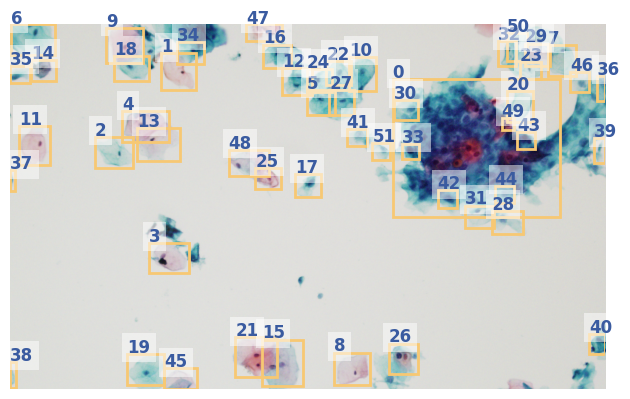

Pominięto komórkę 38 - wszystkie features równe 0


In [46]:
%matplotlib inline
features_list, predicted_classed_fused, probs, probs_list, df_preds, bbox_image_path, crop_paths = get_info(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\LSIL\pow 10\28a.bmp')

In [47]:
pred, attn, output = predict_attention(model, probs_list, 'test', device, CLASS_NAMES)

In [48]:
output

array([0.292, 0.626, 0.082], dtype=float32)

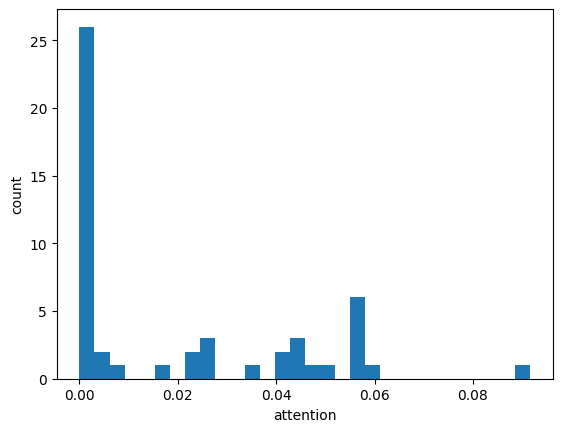

In [49]:
arr = np.asarray(attn)
if arr.ndim > 1:
    arr = arr.ravel()
plt.figure()
plt.hist(arr, bins=30)
plt.xlabel('attention')
plt.ylabel('count')
plt.show()


image 1/1 C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\HSIL\pow 40\50b.bmp: 480x768 7 cells, 1 HSIL_group, 76.3ms
Speed: 3.1ms preprocess, 76.3ms inference, 1.3ms postprocess per image at shape (1, 3, 480, 768)


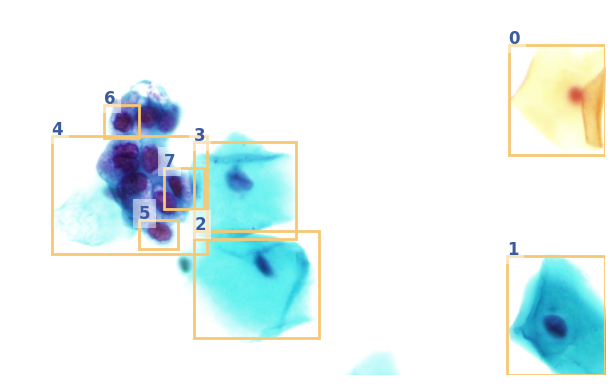

In [50]:
%matplotlib inline
features_list, predicted_classed_fused, probs, probs_list, df_preds, bbox_image_path, crop_paths = get_info(r'C:\Users\aleks\OneDrive\Documents\inzynierka\data\LBC_slides\HSIL\pow 40\50b.bmp')

In [51]:
pred, attn, output = predict_attention(model, probs_list, 'test', device, CLASS_NAMES)

In [52]:
output

array([0.622, 0.17 , 0.208], dtype=float32)

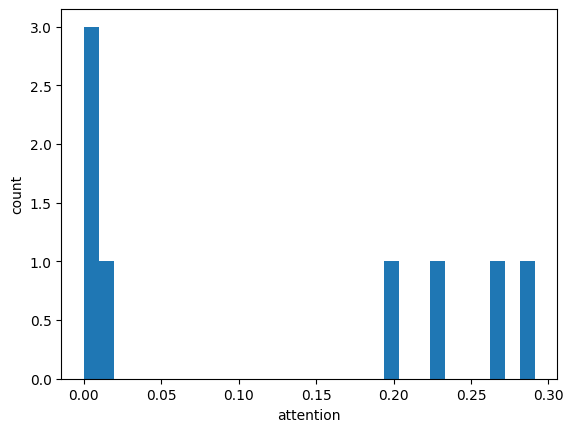

In [53]:
arr = np.asarray(attn)
if arr.ndim > 1:
    arr = arr.ravel()
plt.figure()
plt.hist(arr, bins=30)
plt.xlabel('attention')
plt.ylabel('count')
plt.show()

In [54]:
test_df = pd.DataFrame(test_data)

In [55]:

CLASS_MAPPING = {
    0: 'HSIL',
    1: 'LSIL',
    2: 'NSIL' 
}

def get_mil_test_results(model, test_df, slide_probs_col='slide_probs', label_col='label'):
   
    model.eval()
    results = []
    
    with torch.no_grad():
        for index, row in test_df.iterrows():
            slide_id = row.name 
            true_class_num = row[label_col]
            cell_probs_str = row[slide_probs_col]

            true_class_str = CLASS_MAPPING.get(true_class_num, f'UNKNOWN_{true_class_num}')

            try:
                cell_probs_np = _to_2d_float_array(cell_probs_str)
            except ValueError as e:
                print(e)
                continue
            
            if cell_probs_np.ndim == 1:
                cell_probs_np = np.expand_dims(cell_probs_np, axis=0)
            
            input_tensor = torch.from_numpy(cell_probs_np).float()
            input_tensor = input_tensor.unsqueeze(0) 
            
            output, _ = model(input_tensor) 

            probs_vector = torch.softmax(output.squeeze(0), dim=-1).cpu().numpy()
            
            probs_vector_rounded = np.round(probs_vector, 3) 
            
            predicted_index = np.argmax(probs_vector_rounded)
            predicted_class_str = CLASS_MAPPING.get(predicted_index, f'UNKNOWN_{predicted_index}')

            results.append({
                'True Class': true_class_str,
                'Predicted Class': predicted_class_str,
                'Probabilities Vector': probs_vector_rounded.tolist() 
            })

    return pd.DataFrame(results)

In [56]:
get_mil_test_results(model, test_df, slide_probs_col='slides', label_col='labels')

,True Class,Predicted Class,Probabilities Vector
0,NSIL,NSIL,"[0.0010000000474974513, 0.0, 0.9990000128746033]"
1,HSIL,HSIL,"[0.671999990940094, 0.14900000393390656, 0.179..."
2,LSIL,HSIL,"[0.5789999961853027, 0.2199999988079071, 0.201..."
3,LSIL,LSIL,"[0.25, 0.6790000200271606, 0.07100000232458115]"
4,HSIL,LSIL,"[0.3580000102519989, 0.5379999876022339, 0.104..."
5,HSIL,HSIL,"[0.7429999709129333, 0.08500000089406967, 0.17..."
6,HSIL,HSIL,"[0.7200000286102295, 0.09799999743700027, 0.18..."
7,NSIL,HSIL,"[0.46700000762939453, 0.30300000309944153, 0.2..."
8,HSIL,HSIL,"[0.6940000057220459, 0.1379999965429306, 0.167..."
9,NSIL,NSIL,"[0.0010000000474974513, 0.0, 0.9990000128746033]"
